# Pattern Waiting Times

This notebook calculates the expected waiting time for a coin-toss
pattern using an absorbing Markov chain and validates the exact result
with Monte Carlo simulation.

For a target pattern, each transient state represents the longest suffix
of the observed sequence that is also a prefix of the target pattern.

If $Q$ is the transition matrix between transient states, the expected
waiting-time vector satisfies

$$
(I-Q)E=\mathbf{1}.
$$

The first entry of $E$ gives the expected waiting time when starting
with no matched symbols.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def validate_pattern(pattern):
    """Check that the pattern is a non-empty string containing only H and T."""

    if not isinstance(pattern, str) or len(pattern) == 0:
        raise ValueError("Pattern must be a non-empty string.")

    if any(symbol not in {"H", "T"} for symbol in pattern):
        raise ValueError("Pattern must contain only 'H' and 'T'.")


def generate_states(pattern):
    """Generate all prefix states, including the absorbing state."""

    validate_pattern(pattern)

    return [
        pattern[:length]
        for length in range(len(pattern) + 1)
    ]

In [2]:
states = generate_states("HTH")
print(states)

['', 'H', 'HT', 'HTH']


In [3]:
def next_state(current_state, symbol, pattern):
    """
    Return the longest suffix of the updated sequence
    that is also a prefix of the target pattern.
    """

    candidate = current_state + symbol

    for length in range(
        min(len(candidate), len(pattern)),
        0,
        -1
    ):
        suffix = candidate[-length:]
        prefix = pattern[:length]

        if suffix == prefix:
            return suffix

    return ""

In [4]:
pattern = "HTH"

tests = [
    ("", "H"),
    ("", "T"),
    ("H", "H"),
    ("H", "T"),
    ("HT", "H"),
    ("HT", "T")
]

for state, symbol in tests:
    result = next_state(state, symbol, pattern)
    print(f"{state!r} + {symbol} -> {result!r}")
    

'' + H -> 'H'
'' + T -> ''
'H' + H -> 'H'
'H' + T -> 'HT'
'HT' + H -> 'HTH'
'HT' + T -> ''


## Transition Matrix

For each transient state, the next coin toss moves the process to another
prefix state. With a fair coin, the transitions caused by $H$ and $T$
each have probability $0.5$.

Once the complete pattern has appeared, the process remains in the
absorbing state.

In [5]:
def build_transition_matrix(pattern, p_head=0.5):

    validate_pattern(pattern)

    if not 0 <= p_head <= 1:
        raise ValueError("p_head must lie between 0 and 1.")

    states = generate_states(pattern)
    state_index = {
        state: index
        for index, state in enumerate(states)
    }

    P = np.zeros((len(states), len(states)))

    for state in states[:-1]:
        row = state_index[state]

        next_h = next_state(state, "H", pattern)
        next_t = next_state(state, "T", pattern)

        P[row, state_index[next_h]] += p_head
        P[row, state_index[next_t]] += 1 - p_head

    P[-1, -1] = 1.0

    return P, states

In [6]:
P, states = build_transition_matrix("HTH")

print("States:", states)
print("\nTransition matrix:")
print(P)
print("\nRow sums:")
print(P.sum(axis=1))

States: ['', 'H', 'HT', 'HTH']

Transition matrix:
[[0.5 0.5 0.  0. ]
 [0.  0.5 0.5 0. ]
 [0.5 0.  0.  0.5]
 [0.  0.  0.  1. ]]

Row sums:
[1. 1. 1. 1.]


## Exact Expected Waiting Time

Let $Q$ be the submatrix containing transitions between transient
states. If $E_i$ is the expected remaining waiting time from state
$i$, then

$$
E_i = 1 + \sum_j Q_{ij}E_j.
$$

In matrix form,

$$
(I-Q)E=\mathbf{1}.
$$

Solving this linear system gives the expected waiting time from every
transient state.

In [7]:
def expected_waiting_times(pattern, p_head=0.5):
    """Return the expected waiting time from every transient state."""

    P, states = build_transition_matrix(pattern, p_head)

    transient_states = states[:-1]
    Q = P[:-1, :-1]

    identity = np.eye(len(Q))
    ones = np.ones(len(Q))

    expected_times = np.linalg.solve(
        identity - Q,
        ones
    )

    return {
        state: expected_times[index]
        for index, state in enumerate(transient_states)
    }


def expected_waiting_time(pattern, p_head=0.5):
    """Return the expected waiting time from the empty initial state."""

    expected_times = expected_waiting_times(pattern, p_head)
    return expected_times[""]

In [8]:
patterns = ["H", "HH", "HHH", "HTH", "HTTH"]

for pattern in patterns:
    result = expected_waiting_time(pattern)
    print(f"{pattern}: {result:.1f}")

H: 2.0
HH: 6.0
HHH: 14.0
HTH: 10.0
HTTH: 18.0


## Monte Carlo Validation

The exact Markov-chain result can be checked by repeatedly simulating
coin tosses until the target pattern appears.

As the number of trials increases, the simulated average waiting time
should approach the exact value.

In [9]:
def simulate_waiting_time(pattern, p_head=0.5, rng=None):
    """Simulate one waiting time for the target pattern."""

    validate_pattern(pattern)

    if rng is None:
        rng = np.random.default_rng()

    state = ""
    steps = 0

    while state != pattern:
        symbol = "H" if rng.random() < p_head else "T"
        state = next_state(state, symbol, pattern)
        steps += 1

    return steps


def monte_carlo_waiting_time(
    pattern,
    trials=10_000,
    p_head=0.5,
    seed=None
):
    """Estimate the expected waiting time by Monte Carlo simulation."""

    if trials <= 0:
        raise ValueError("trials must be positive.")

    rng = np.random.default_rng(seed)

    waiting_times = np.array([
        simulate_waiting_time(pattern, p_head, rng)
        for _ in range(trials)
    ])

    estimate = np.mean(waiting_times)
    standard_error = (
        np.std(waiting_times, ddof=1)
        / np.sqrt(trials)
    )

    return estimate, standard_error

In [10]:
pattern = "HTTH"

exact_value = expected_waiting_time(pattern)

estimate, standard_error = monte_carlo_waiting_time(
    pattern,
    trials=100_000,
    seed=42
)

print(f"Pattern: {pattern}")
print(f"Exact value:          {exact_value:.4f}")
print(f"Monte Carlo estimate: {estimate:.4f}")
print(f"Standard error:       {standard_error:.4f}")

Pattern: HTTH
Exact value:          18.0000
Monte Carlo estimate: 18.0376
Standard error:       0.0459


## Convergence

The Monte Carlo estimate becomes more stable as the number of trials
increases. Its typical sampling error decreases at the rate

$$
O\left(N^{-1/2}\right),
$$

where $N$ is the number of simulated trials.

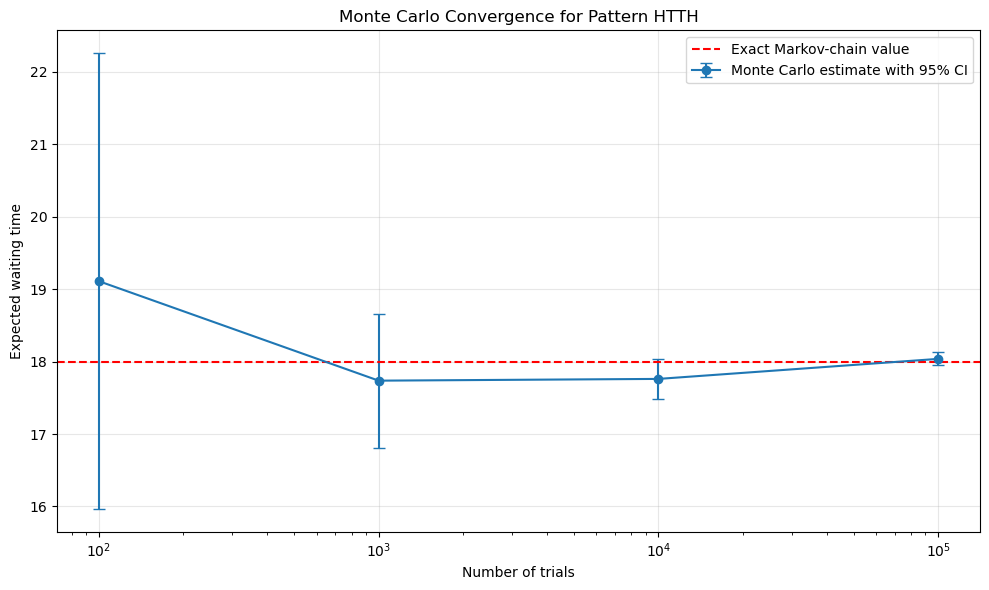

In [11]:
trial_sizes = np.array([
    100,
    1_000,
    10_000,
    100_000
])

estimates = []
standard_errors = []

for trials in trial_sizes:
    current_estimate, current_se = monte_carlo_waiting_time(
        pattern="HTTH",
        trials=trials,
        seed=42
    )

    estimates.append(current_estimate)
    standard_errors.append(current_se)

estimates = np.array(estimates)
standard_errors = np.array(standard_errors)

plt.figure(figsize=(10, 6))

plt.errorbar(
    trial_sizes,
    estimates,
    yerr=1.96 * standard_errors,
    marker="o",
    capsize=4,
    label="Monte Carlo estimate with 95% CI"
)

plt.axhline(
    exact_value,
    color="red",
    linestyle="--",
    label="Exact Markov-chain value"
)

plt.xscale("log")
plt.xlabel("Number of trials")
plt.ylabel("Expected waiting time")
plt.title("Monte Carlo Convergence for Pattern HTTH")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

The absorbing Markov-chain method provides an exact expected waiting
time for any finite coin-toss pattern.

For the pattern `HTTH`, the exact expected waiting time is $18$.
A Monte Carlo simulation with 100,000 trials produced an estimate of
$18.0376$, and the exact value lay within the estimated 95% confidence
interval.

The comparison also illustrates how pattern overlap affects waiting
times and how Monte Carlo uncertainty decreases as the number of trials
increases.